# Marketing A/B Test - EDA

Exploring the marketing A/B test dataset before running the significance test. Checks group sizes, conversion rates, ad exposure, and when users were most exposed to ads.

Loading the raw data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/marketing_AB.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [2]:
df.shape, df.dtypes

((588101, 6),
 user id           int64
 test group       object
 converted          bool
 total ads         int64
 most ads day     object
 most ads hour     int64
 dtype: object)

### group balance

The test is heavily imbalanced: almost everyone is in the ad group, only a small slice got the psa (public service announcement) control. Worth keeping in mind, it affects how wide the confidence interval is on the smaller group.

In [3]:
group_counts = df["test group"].value_counts()
group_share = df["test group"].value_counts(normalize=True).round(4)
print(group_counts)
print(group_share)

test group
ad     564577
psa     23524
Name: count, dtype: int64
test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64


In [4]:
# psa is a small slice of the data, keep that in mind for the CI later
smaller = group_share.min()
print(f"{group_share.idxmin()} is {smaller:.1%} of users")

psa is 4.0% of users


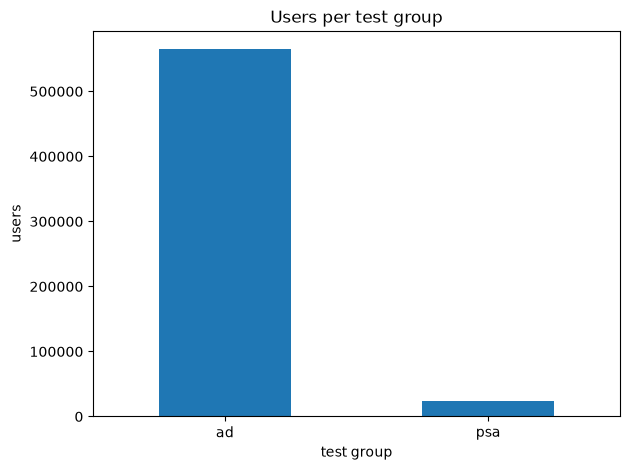

In [5]:
group_counts.plot(kind="bar", title="Users per test group")
plt.ylabel("users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/group_balance.png", dpi=150, bbox_inches="tight")
plt.show()

### conversion rate

Checking overall conversion rate, then conversion rate by group. This is just descriptive, the actual significance test is in the next notebook.

In [6]:
overall_rate = df["converted"].mean()
print(f"overall conversion rate: {overall_rate:.2%}")

rate_by_group = df.groupby("test group")["converted"].agg(["count", "sum", "mean"])
rate_by_group.columns = ["users", "conversions", "conversion_rate"]
rate_by_group

overall conversion rate: 2.52%


,users,conversions,conversion_rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


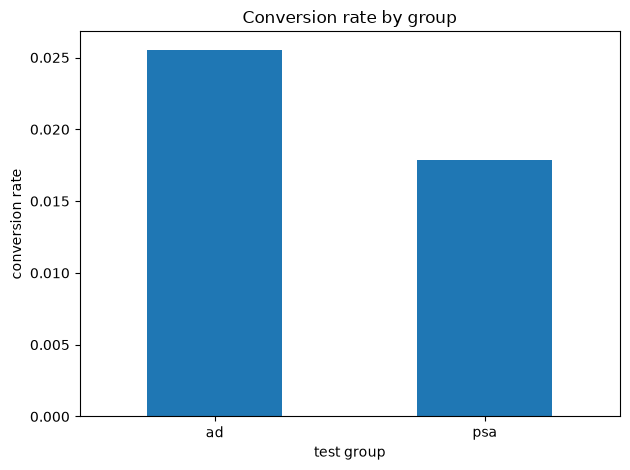

In [7]:
rate_by_group["conversion_rate"].plot(kind="bar", title="Conversion rate by group")
plt.ylabel("conversion rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/conversion_rate_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

### ad exposure

Checking how many ads users were shown, and whether ad exposure relates to conversion.

In [8]:
df["total ads"].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64

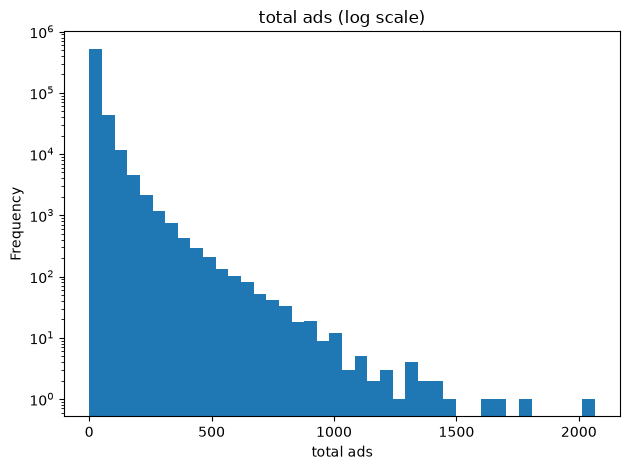

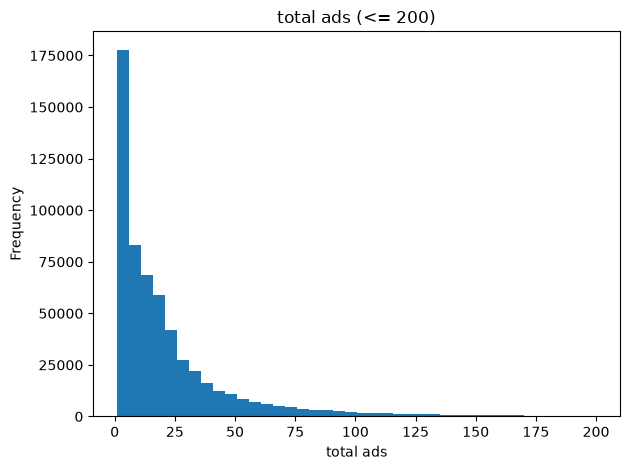

In [9]:
# log scale, the linear histogram gets wrecked by a few outliers with 500+ ads
df["total ads"].plot(kind="hist", bins=40, log=True, title="total ads (log scale)")
plt.xlabel("total ads")
plt.tight_layout()
plt.savefig("../results/total_ads_log_scale.png", dpi=150, bbox_inches="tight")
plt.show()

df[df["total ads"] <= 200]["total ads"].plot(kind="hist", bins=40, title="total ads (<= 200)")
plt.xlabel("total ads")
plt.tight_layout()
plt.savefig("../results/total_ads_under_200.png", dpi=150, bbox_inches="tight")
plt.show()

Checking whether users who saw more ads were more likely to convert.

In [10]:
df.groupby("converted")["total ads"].mean()

converted
False    23.291495
True     83.887759
Name: total ads, dtype: float64

### timing

Checking which day and hour users saw the most ads, mostly to understand the ad delivery pattern, not something used in the significance test itself.

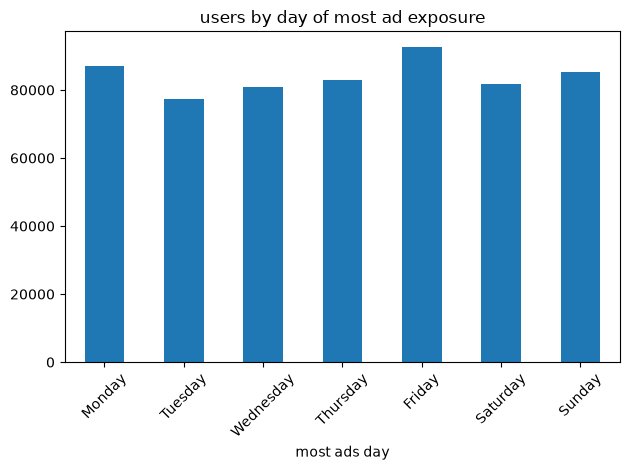

In [11]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["most ads day"] = pd.Categorical(df["most ads day"], categories=day_order, ordered=True)

df["most ads day"].value_counts().sort_index().plot(kind="bar", title="users by day of most ad exposure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/ads_by_day.png", dpi=150, bbox_inches="tight")
plt.show()

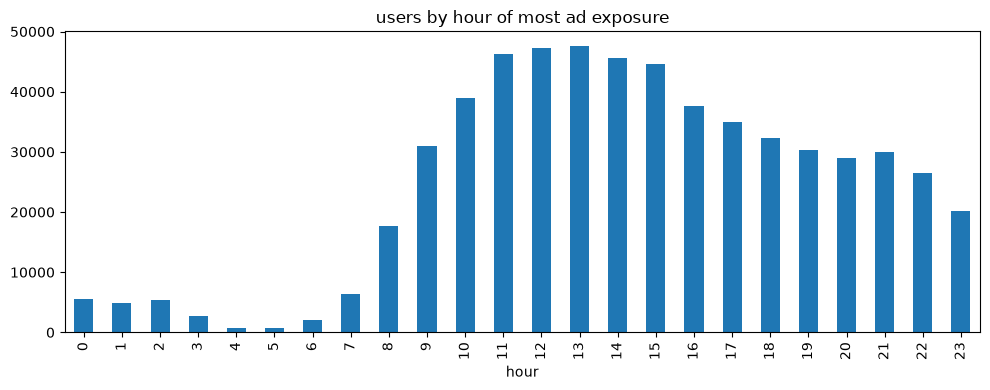

In [12]:
df["most ads hour"].value_counts().sort_index().plot(kind="bar", title="users by hour of most ad exposure", figsize=(10, 4))
plt.xlabel("hour")
plt.tight_layout()
plt.savefig("../results/ads_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()